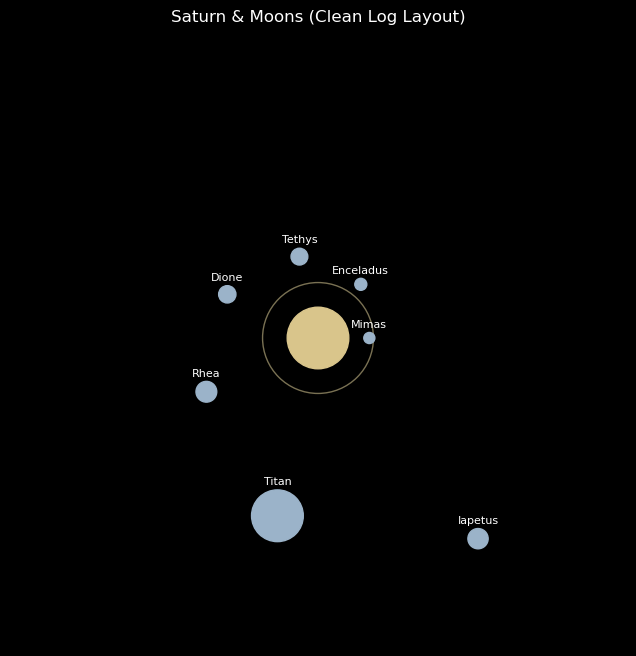

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

# -----------------------------
# Data
# -----------------------------
moons = [
    {"name": "Mimas", "distance": 185539 * u.km, "radius": 198 * u.km},
    {"name": "Enceladus", "distance": 238042 * u.km, "radius": 252 * u.km},
    {"name": "Tethys", "distance": 294619 * u.km, "radius": 531 * u.km},
    {"name": "Dione", "distance": 377396 * u.km, "radius": 561 * u.km},
    {"name": "Rhea", "distance": 527108 * u.km, "radius": 764 * u.km},
    {"name": "Titan", "distance": 1221870 * u.km, "radius": 2575 * u.km},
    {"name": "Iapetus", "distance": 3560820 * u.km, "radius": 734 * u.km},
]

# -----------------------------
# Log distance scaling
# -----------------------------
distances = np.array([m["distance"].value for m in moons])
log_dist = np.log10(distances)

# normalize nicely
log_dist = (log_dist - log_dist.min()) / (log_dist.max() - log_dist.min())
log_dist = log_dist * 8 + 2   # compact range

# -----------------------------
# Layout
# -----------------------------
angles = np.linspace(0, 2*np.pi, len(moons), endpoint=False)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# 🪐 Saturn (FIXED SIZE — always visible)
saturn_radius_plot = 1.2   # <- THIS is the key
saturn = plt.Circle((0, 0), saturn_radius_plot, color="#d9c58b")
ax.add_patch(saturn)

# subtle ring
ring = plt.Circle((0, 0), saturn_radius_plot * 1.8,
                  fill=False, color="#cbbd8b", linewidth=1, alpha=0.6)
ax.add_patch(ring)

# 🌕 Moons
for moon, r_dist, angle in zip(moons, log_dist, angles):
    moon_r = 0.15 + (moon["radius"].value / 3000)  # small relative scaling

    x = r_dist * np.cos(angle)
    y = r_dist * np.sin(angle)

    moon_circle = plt.Circle((x, y), moon_r, color="#9bb3c9")
    ax.add_patch(moon_circle)

    ax.text(x, y + moon_r + 0.2, moon["name"],
            color="white", fontsize=8, ha='center')

# -----------------------------
# Framing
# -----------------------------
ax.set_xlim(-12, 12)
ax.set_ylim(-12, 12)
ax.set_aspect('equal')

ax.set_title("Saturn & Moons (Clean Log Layout)",
             color="white")

ax.axis('off')

plt.show()

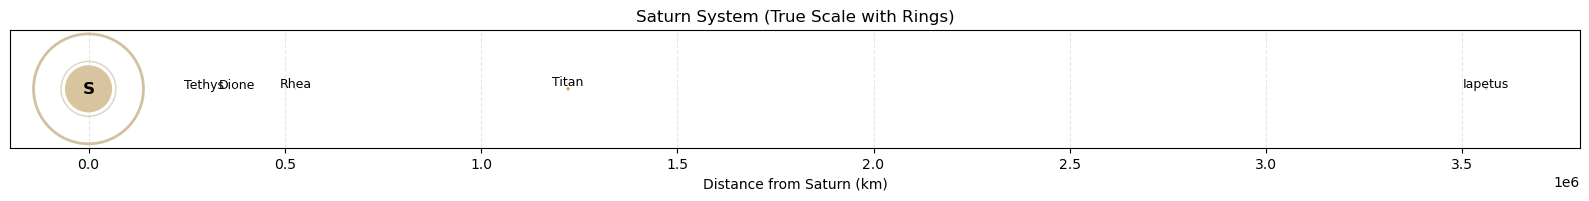

In [1]:
import matplotlib.pyplot as plt
import astropy.units as u

# -----------------------------
# NASA-style colors
# -----------------------------
colors = {
    "Saturn": "#d8c59f",   # pale golden
    "Titan": "#d2a85a",    # orange haze
    "Rhea": "#cfcfcf",
    "Dione": "#d9d9d9",
    "Tethys": "#e5e5e5",
    "Iapetus": "#b0b0b0",
}

# -----------------------------
# Real data
# -----------------------------
bodies = {
    "Saturn": {"radius": 58232 * u.km, "distance": 0 * u.km},
    "Tethys": {"radius": 531 * u.km, "distance": 294660 * u.km},
    "Dione": {"radius": 561 * u.km, "distance": 377400 * u.km},
    "Rhea": {"radius": 764 * u.km, "distance": 527040 * u.km},
    "Titan": {"radius": 2575 * u.km, "distance": 1221870 * u.km},
    "Iapetus": {"radius": 734 * u.km, "distance": 3561300 * u.km},
}

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 6))

# -----------------------------
# Saturn body
# -----------------------------
saturn_radius = bodies["Saturn"]["radius"].to_value(u.km)

saturn = plt.Circle(
    (0, 0),
    saturn_radius,
    color=colors["Saturn"],
    zorder=3
)
ax.add_patch(saturn)

# Label
ax.text(0, 0, "S", ha="center", va="center", fontsize=12, weight="bold")

# -----------------------------
# Rings (simplified but scaled)
# -----------------------------
# Saturn rings span roughly 70,000 km to 140,000 km from center
ring_inner = 70000
ring_outer = 140000

ring = plt.Circle(
    (0, 0),
    ring_outer,
    fill=False,
    edgecolor="#bfa77a",
    linewidth=2,
    alpha=0.7,
    zorder=2
)
ax.add_patch(ring)

# optional inner boundary
ring_inner_circle = plt.Circle(
    (0, 0),
    ring_inner,
    fill=False,
    edgecolor="#bfa77a",
    linewidth=1,
    alpha=0.5,
    zorder=2
)
ax.add_patch(ring_inner_circle)

# -----------------------------
# Moons
# -----------------------------
for name, data in bodies.items():
    if name == "Saturn":
        continue

    dist = data["distance"].to_value(u.km)
    radius = data["radius"].to_value(u.km)

    moon = plt.Circle(
        (dist, 0),
        radius,
        color=colors[name],
        zorder=4
    )
    ax.add_patch(moon)

    ax.text(dist, radius * 3, name, ha="center", fontsize=9)

# -----------------------------
# Styling
# -----------------------------
ax.set_xlim(-200000, 3800000)
ax.set_ylim(-150000, 150000)

# 🔥 critical: keeps Saturn circular
ax.set_aspect('equal', adjustable='box')

ax.set_yticks([])
ax.set_xlabel("Distance from Saturn (km)")
ax.set_title("Saturn System (True Scale with Rings)")

ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

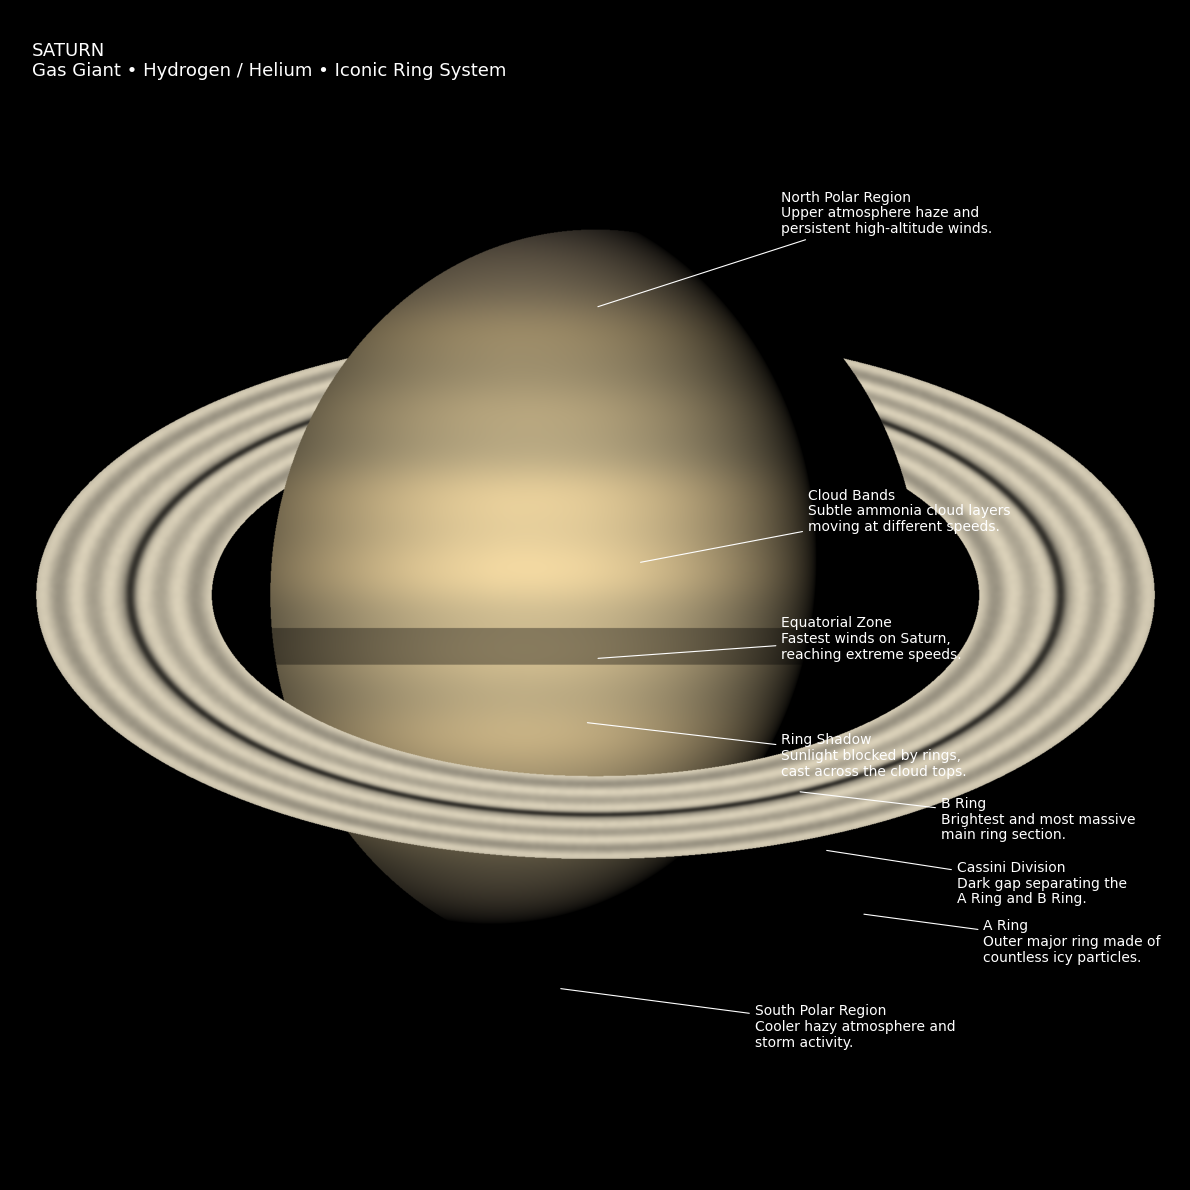

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ==================================================
# REALISTIC SATURN WITH RINGS + LABELS + DESCRIPTIONS
# ==================================================

np.random.seed(7)

size = 2200
x = np.linspace(-1.8, 1.8, size)
y = np.linspace(-1.6, 1.6, size)
X, Y = np.meshgrid(x, y)

# --------------------------------------------------
# Ring tilt (apparent)
# --------------------------------------------------
tilt = 0.42
Yr = Y / tilt
Rring = np.sqrt(X**2 + Yr**2)

# Ring boundaries
ring_inner = 1.18
ring_outer = 1.72

ring_mask = (Rring >= ring_inner) & (Rring <= ring_outer)

# --------------------------------------------------
# Planet sphere
# --------------------------------------------------
Rp = np.sqrt(X**2 + Y**2)
planet = Rp <= 1.0

# --------------------------------------------------
# Saturn atmosphere bands
# --------------------------------------------------
lat = Y * 10

bands = (
    0.55
    + 0.06*np.sin(lat)
    + 0.03*np.sin(lat*2.8)
)

noise = gaussian_filter(np.random.normal(size=(size, size)), sigma=16)
texture = bands + 0.04*noise
texture = (texture - texture.min()) / (texture.max() - texture.min())

rgb = np.zeros((size, size, 3))
rgb[:,:,0] = 0.82 + texture*0.18
rgb[:,:,1] = 0.75 + texture*0.14
rgb[:,:,2] = 0.58 + texture*0.08

# Polar slight blue haze
polar = np.clip((np.abs(Y)-0.72)/0.28, 0, 1)
rgb[:,:,2] += polar*0.08

# --------------------------------------------------
# Lighting / sphere shading
# --------------------------------------------------
light = np.clip(1 - ((X + 0.32)**2 + (Y - 0.10)**2), 0, 1)
light = light**0.58

rgb *= light[:,:,None]
rgb *= np.clip(1 - Rp**2*0.32, 0.58, 1.0)[:,:,None]

# --------------------------------------------------
# Rings
# --------------------------------------------------
rings = np.zeros((size, size, 3))

ring_noise = gaussian_filter(np.random.normal(size=(size, size)), sigma=4)
ring_tex = 0.78 + 0.12*np.sin(Rring*60) + 0.06*ring_noise

# Cassini Division
cassini = np.exp(-((Rring-1.43)**2)/(2*0.012**2))
ring_tex -= cassini*0.45

# A/B ring brightness variation
ring_tex += np.exp(-((Rring-1.33)**2)/(2*0.03**2))*0.08
ring_tex += np.exp(-((Rring-1.55)**2)/(2*0.04**2))*0.05

rings[:,:,0] = ring_tex * 0.92
rings[:,:,1] = ring_tex * 0.88
rings[:,:,2] = ring_tex * 0.78

rings[~ring_mask] = 0
rings = np.clip(rings, 0, 1)

# --------------------------------------------------
# Ring shadow on planet
# --------------------------------------------------
shadow_band = (np.abs(Y + 0.14) < 0.05) & planet
rgb[shadow_band] *= 0.65

# --------------------------------------------------
# Compose image layers
# Rings behind planet first
# --------------------------------------------------
final = np.zeros_like(rgb)

# Back rings
back = ring_mask & (Y > 0)
final[back] = rings[back]

# Planet over back rings
final[planet] = rgb[planet]

# Front rings
front = ring_mask & (Y <= 0)
final[front] = rings[front]

final = np.clip(final, 0, 1)

# ==================================================
# Plot
# ==================================================
fig, ax = plt.subplots(figsize=(15, 12), facecolor="black")
ax.imshow(final, origin="lower")
ax.axis("off")
ax.set_facecolor("black")

# --------------------------------------------------
# Label helper
# --------------------------------------------------
def label(txt, xy, xytext):
    ax.annotate(
        txt,
        xy=xy,
        xytext=xytext,
        color="white",
        fontsize=10,
        linespacing=1.15,
        arrowprops=dict(arrowstyle="-", lw=0.8, color="white")
    )

# ==================================================
# Labels + Descriptions
# ==================================================

label(
    "North Polar Region\nUpper atmosphere haze and\npersistent high-altitude winds.",
    (1100, 1640), (1450, 1780)
)

label(
    "Cloud Bands\nSubtle ammonia cloud layers\nmoving at different speeds.",
    (1180, 1160), (1500, 1220)
)

label(
    "Equatorial Zone\nFastest winds on Saturn,\nreaching extreme speeds.",
    (1100, 980), (1450, 980)
)

label(
    "Ring Shadow\nSunlight blocked by rings,\ncast across the cloud tops.",
    (1080, 860), (1450, 760)
)

label(
    "B Ring\nBrightest and most massive\nmain ring section.",
    (1480, 730), (1750, 640)
)

label(
    "Cassini Division\nDark gap separating the\nA Ring and B Ring.",
    (1530, 620), (1780, 520)
)

label(
    "A Ring\nOuter major ring made of\ncountless icy particles.",
    (1600, 500), (1830, 410)
)

label(
    "South Polar Region\nCooler hazy atmosphere and\nstorm activity.",
    (1030, 360), (1400, 250)
)

# --------------------------------------------------
# Title
# --------------------------------------------------
ax.text(
    40, 2140,
    "SATURN\nGas Giant • Hydrogen / Helium • Iconic Ring System",
    color="white",
    fontsize=13,
    ha="left",
    va="top"
)

plt.tight_layout()
plt.show()